# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [41]:
#outline:
# 1. make class card: for representing one card
# 2. make class deck: for holding multiple cards
# 3. make class shuffle: to shuffle the deck
# 4. make class draw: to draw the next card

import random

class card:
    
    def __init__(self,suit,rank):
        self.suit=suit   #assigning suit to the card
        self.rank=rank   #assigning rank to the card
        
    def __str__(self):
        return str(self.rank)+" of "+str(self.suit)  


class deck:
    
    def __init__(self, num_decks=1):
        self.cards = []
        
        suits =["Hearts", "Diamonds", "Clubs", "Spades"]  #list of possible suits
        ranks = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]   #list of possible ranks
        
        for d in range(num_decks):   #to make multiple decks if the player wants
            for suit in suits:
                for rank in ranks:
                    self.cards.append(card(suit, rank))   #making card object, and adding to deck list
        
        ## didn't understand how to work the plastic card so asked LLM and it told me the logic I should be using  
        
        self.plastic_position=random.randint(0, len(self.cards)-1)  #choosing random position where the plastic card will go 
        self.cards.insert(self.plastic_position, "PLASTIC")  #inserting the plastic card in the deck
        
        self.shuffle()  #for shuffling deck when its created
    
    
    def shuffle(self):
        random.shuffle(self.cards)
    
    
    def draw(self):
        
        card = self.cards.pop(0)  #gives the topmost card of deck
        
        if card == "PLASTIC":  #to check if we reached the plastic card
            print("Plastic card reached. Reshuffling deck.")
            self.shuffle()
            card = self.cards.pop(0)
            
        return card

In [42]:
deck = deck(1)

card1 = deck.draw()
card2 = deck.draw()

print(card1)
print(card2)

3 of Hearts
4 of Clubs


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [13]:
#picture added for answer (sorry for the bad handwriting!)

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [43]:
class card:    
    def __init__(self,suit,rank):
        self.suit=suit  #assigning suit to the card
        self.rank=rank  #assigning rank to the card
    
    def __str__(self):
        pass

class deck:    
    def __init__(self, num_decks=1):
        self.cards=[]
        self.plastic_position = None
    
    def shuffle(self):
        pass
    
    def draw(self):
        pass

class hand:    
    def __init__(self):
        self.cards=[]    
    def add_card(self,card):
        pass
    
    def show_hand(self):
        pass

class player:    
    def __init__(self, name):
        self.name=name
        self.hand=hand()
    
    def take_card(self,card):
        pass    
    def show_hand(self):
        pass


class game:    
    def __init__(self, num_players):
        self.deck=deck()
        self.players=[]
    
    def deal_cards(self):
        pass
    
    def play_round(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [44]:
#outline:
# 1. make class card: for representing one card
# 2. make class deck: for holding all cards and plastic card
# 3. make class hand: for storing cards of a player
# 4. make class player: basic player class
# 5. make class dealer and humanplayer
# 6. make class game: for running one round

import random

class card:
    
    def __init__(self, suit, rank):
        self.suit=suit   #assigning suit to the card
        self.rank=rank   #assigning rank to the card
    
    def __str__(self):
        return str(self.rank)+" of "+str(self.suit)   #printing card in readable form


class deck:
    
    def __init__(self, num_decks=1):
        self.cards=[]        
        suits=["Hearts", "Diamonds", "Clubs", "Spades"]   #list of possible suits
        ranks=["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]   #list of possible ranks
        
        for d in range(num_decks):   #to make multiple decks if needed
            for suit in suits:
                for rank in ranks:
                    self.cards.append(card(suit, rank))   #making card object and adding it to deck
        
        self.plastic_position=random.randint(0, len(self.cards)-1)   #choosing random place for plastic card
        self.cards.insert(self.plastic_position, "PLASTIC")   #inserting plastic card into deck
        
        self.shuffle()   #shuffling the deck when created
    
    def shuffle(self):
        random.shuffle(self.cards)   #shuffles all cards in deck
    
    def draw(self):
        card_drawn=self.cards.pop(0)   #removes and gives top card
        
        if card_drawn=="PLASTIC":   #to check if plastic card was reached
            print("plastic card reached. reshuffling deck.")
            self.shuffle()
            card_drawn=self.cards.pop(0)   #draw next card after shuffle
        
        return card_drawn


class hand:
    
    def __init__(self):
        self.cards=[]   #list to store cards in hand
    
    def add_card(self, card_obj):
        self.cards.append(card_obj)   #adding one card into hand
    
    def show_hand(self):
        for c in self.cards:
            print(c)   #printing each card in hand
    
    def get_value(self):
        total=0
        
        for c in self.cards:
            if c.rank=="A":
                total=total+11   #ace value taken as 11 for now
            elif c.rank=="J" or c.rank=="Q" or c.rank=="K":
                total=total+10   #all face cards count as 10
            else:
                total=total+int(c.rank)   #number cards keep their value
        
        return total
    
    def clear_hand(self):
        self.cards=[]   #for clearing all cards from hand for new round


class player:
    
    def __init__(self, name):
        self.name=name   #storing player's name
        self.hand=hand()   #each player starts with an empty hand
    
    def take_card(self, card_obj):
        self.hand.add_card(card_obj)   #adds drawn card into player's hand
    
    def show_hand(self):
        print(self.name+"'s hand:")   #printing whose hand it is
        self.hand.show_hand()
    
    def get_hand_value(self):
        return self.hand.get_value()   #returns total value of player's hand


class dealer(player):
    
    def __init__(self):
        player.__init__(self, "Dealer")   #dealer is also a player
    
    def show_first_card(self):
        print("Dealer's first card:")
        if len(self.hand.cards)>0:
            print(self.hand.cards[0])   #showing only first card of dealer


class humanplayer(player):
    
    def __init__(self, name):
        player.__init__(self, name)   #human player is also a player


class game:
    
    def __init__(self, player_name, num_decks=1):
        self.deck=deck(num_decks)   #creating the deck
        self.dealer=dealer()   #creating dealer object
        self.player=humanplayer(player_name)   #creating human player object
    
    def deal_cards(self):
        self.player.take_card(self.deck.draw())   #first card to player
        self.dealer.take_card(self.deck.draw())   #first card to dealer
        self.player.take_card(self.deck.draw())   #second card to player
        self.dealer.take_card(self.deck.draw())   #second card to dealer
    
    def show_hands(self):
        self.player.show_hand()
        print("Total value:", self.player.get_hand_value())   #show total of player's hand
        print()
        self.dealer.show_first_card()   #show only one dealer card
    
    def play_round(self):
        self.reset_round()   #clears old cards before starting new round
        self.deal_cards()   #deals cards first
        self.show_hands()   #then shows hands
    
    def reset_round(self):
        self.player.hand.clear_hand()   #clears player's hand
        self.dealer.hand.clear_hand()   #clears dealer's hand

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [45]:
#testing game for several rounds

g=game("Pearl", 1)   #creating a game with 1 human player and 1 dealer

for i in range(3):   #playing 3 rounds
    print("Round", i+1)
    g.play_round()
    
    print("--------------------")

Round 1
Pearl's hand:
9 of Spades
10 of Diamonds
Total value: 19

Dealer's first card:
2 of Diamonds
--------------------
Round 2
Pearl's hand:
10 of Clubs
A of Clubs
Total value: 21

Dealer's first card:
3 of Clubs
--------------------
Round 3
Pearl's hand:
9 of Diamonds
K of Diamonds
Total value: 19

Dealer's first card:
2 of Hearts
--------------------


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [46]:
class countingplayer(player):
    
    def __init__(self,name):
        player.__init__(self,name)   #counting player is also a player
        self.count=0   #keeps track of card counting value
    
    def update_count(self,card_obj):
        #assigning values to cards based on strategy
        
        if card_obj.rank in ["2","3","4","5","6"]:
            self.count=self.count+1
        
        elif card_obj.rank in ["7","8","9"]:
            self.count=self.count+0
        
        else:
            self.count=self.count-1
    
    def see_card(self,card_obj):
        #called whenever a card is seen in the game
        self.update_count(card_obj)
    
    def decide(self):
        #deciding whether to hit or stay
        
        if self.count<=-2:   #threshold chosen for hitting
            return "hit"
        else:
            return "stay"

In [47]:
#testing counting player strategy

cp=countingplayer("Counter")

#simulating some cards being seen
cards_seen=[
card("Hearts","5"),
card("Spades","9"),
card("Clubs","K"),
card("Diamonds","3")]

for c in cards_seen:
    cp.see_card(c)
    print("Saw:",c)

print("Current count:",cp.count)
print("Decision:",cp.decide())

Saw: 5 of Hearts
Saw: 9 of Spades
Saw: K of Clubs
Saw: 3 of Diamonds
Current count: 1
Decision: stay


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [53]:
#outline:
# 1. make a dealerstyle player: follows dealer strategy
# 2. make a counting player: follows counting strategy
# 3. make a simulation with 1 counting player, 1 dealer, and 3 other players
# 4. give every player same starting chips
# 5. play 50 rounds or stop if counting player loses all chips
# 6. compute counting player's winnings

import random

class card:
    
    def __init__(self, suit, rank):
        self.suit=suit
        self.rank=rank
    
    def __str__(self):
        return str(self.rank)+" of "+str(self.suit)


class deck:
    
    def __init__(self, num_decks=1):
        self.num_decks=num_decks
        self.cards=[]
        self.make_deck()
        self.shuffle()
    
    def make_deck(self):
        self.cards=[]
        suits=["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks=["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]
        
        for d in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(card(suit, rank))
        
        self.plastic_position=random.randint(0, len(self.cards)-1)
        self.cards.insert(self.plastic_position, "PLASTIC")
    
    def shuffle(self):
        random.shuffle(self.cards)
    
    def draw(self):       
        if len(self.cards)==0:   #if deck gets empty, make fresh deck again
            self.make_deck()
            self.shuffle()
    
        card_drawn=self.cards.pop(0)
    
        while card_drawn=="PLASTIC":   #keep drawing until we get a real card
            self.make_deck()
            self.shuffle()
            card_drawn=self.cards.pop(0)
    
        return card_drawn

class hand:
    
    def __init__(self):
        self.cards=[]
    
    def add_card(self, card_obj):
        self.cards.append(card_obj)
    
    def show_hand(self):
        for c in self.cards:
            print(c)
    
    def get_value(self):
        total=0
        aces=0
        
        for c in self.cards:
            if c.rank=="A":
                total=total+11
                aces=aces+1
            elif c.rank=="J" or c.rank=="Q" or c.rank=="K":
                total=total+10
            else:
                total=total+int(c.rank)
        
        while total>21 and aces>0:
            total=total-10
            aces=aces-1
        
        return total
    
    def clear_hand(self):
        self.cards=[]


class player:
    
    def __init__(self, name, chips=20):
        self.name=name
        self.hand=hand()
        self.chips=chips   #starting chips for player
    
    def take_card(self, card_obj):
        self.hand.add_card(card_obj)
    
    def show_hand(self):
        print(self.name+"'s hand:")
        self.hand.show_hand()
    
    def get_hand_value(self):
        return self.hand.get_value()
    
    def is_busted(self):
        if self.get_hand_value()>21:
            return True
        else:
            return False


class dealer(player):
    
    def __init__(self):
        player.__init__(self, "Dealer", 0)
    
    def show_first_card(self):
        if len(self.hand.cards)>0:
            print(self.hand.cards[0])
    
    def play_turn(self, deck_obj, counting_player=None):
        while self.get_hand_value()<17:
            new_card=deck_obj.draw()
            self.take_card(new_card)
            if counting_player!=None:
                counting_player.see_card(new_card)


class dealerstyleplayer(player):
    
    def __init__(self, name, chips=20):
        player.__init__(self, name, chips)
    
    def play_turn(self, deck_obj, counting_player=None):
        while self.get_hand_value()<17:
            new_card=deck_obj.draw()
            self.take_card(new_card)
            if counting_player!=None:
                counting_player.see_card(new_card)

#got confused here, asked LLM to guide me further
                
class countingplayer(player):
    
    def __init__(self, name, chips=20):
        player.__init__(self, name, chips)
        self.count=0   #keeps running count
    
    def update_count(self, card_obj):
        if card_obj.rank in ["2", "3", "4", "5", "6"]:
            self.count=self.count+1
        elif card_obj.rank in ["7", "8", "9"]:
            self.count=self.count+0
        else:
            self.count=self.count-1
    
    def see_card(self, card_obj):
        self.update_count(card_obj)
    
    def play_turn(self, deck_obj):
        while self.count<=-2 and self.get_hand_value()<21:
            new_card=deck_obj.draw()
            self.take_card(new_card)
            self.see_card(new_card)


def play_50_rounds(verbose=False):
    
    deck_obj=deck(4)   #using 4 decks
    dealer_obj=dealer()
    
    strategy_player=countingplayer("Strategy Player", 20)
    
    other1=dealerstyleplayer("Player 2", 20)
    other2=dealerstyleplayer("Player 3", 20)
    other3=dealerstyleplayer("Player 4", 20)
    
    players=[strategy_player, other1, other2, other3]
    
    starting_chips=strategy_player.chips
    
    round_num=1
    
    while round_num<=50 and strategy_player.chips>0:
        
        dealer_obj.hand.clear_hand()
        for p in players:
            p.hand.clear_hand()
        
        #each player gets 2 cards
        for p in players:
            first_card=deck_obj.draw()
            p.take_card(first_card)
            strategy_player.see_card(first_card)
            
            second_card=deck_obj.draw()
            p.take_card(second_card)
            strategy_player.see_card(second_card)
        
        #dealer gets 2 cards
        dealer_card1=deck_obj.draw()
        dealer_obj.take_card(dealer_card1)
        strategy_player.see_card(dealer_card1)
        
        dealer_card2=deck_obj.draw()
        dealer_obj.take_card(dealer_card2)
        strategy_player.see_card(dealer_card2)
        
        #players take turns
        strategy_player.play_turn(deck_obj)
        other1.play_turn(deck_obj, strategy_player)
        other2.play_turn(deck_obj, strategy_player)
        other3.play_turn(deck_obj, strategy_player)
        
        #dealer turn
        dealer_obj.play_turn(deck_obj, strategy_player)
        
        #compare only strategy player with dealer
        strategy_value=strategy_player.get_hand_value()
        dealer_value=dealer_obj.get_hand_value()
        
        if strategy_player.is_busted():
            strategy_player.chips=strategy_player.chips-1
            result="lost"
        elif dealer_obj.is_busted():
            strategy_player.chips=strategy_player.chips+1
            result="won"
        elif strategy_value>dealer_value:
            strategy_player.chips=strategy_player.chips+1
            result="won"
        elif strategy_value<dealer_value:
            strategy_player.chips=strategy_player.chips-1
            result="lost"
        else:
            result="push"
        
        if verbose==True:
            print("Round", round_num)
            print("Strategy player value:", strategy_value)
            print("Dealer value:", dealer_value)
            print("Strategy player result:", result)
            print("Strategy player chips:", strategy_player.chips)
            print("Current count:", strategy_player.count)
            print("--------------------")
        
        round_num=round_num+1
    
    winnings=strategy_player.chips-starting_chips

    if verbose==True:
        print("Starting chips:", starting_chips)
        print("Ending chips:", strategy_player.chips)
        print("Strategy player's winnings:", winnings)
        print("Rounds played:", round_num-1)

        if strategy_player.chips<=0:
            print("Strategy player ran out of money.")
        else:
            print("Simulation finished 50 rounds.")

    return winnings


#test scenario
play_50_rounds(False)

-20

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


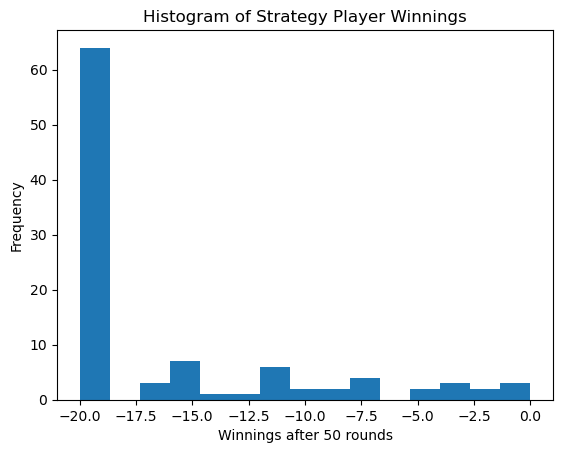

Average winnings per game: -16.29
Average winnings per round: -0.3258
Standard deviation: 5.831462903591139
Probability of net win: 0.0
Probability of net loss: 0.98


In [55]:
import matplotlib.pyplot as plt
import statistics

winnings_list=[]

#run 100 games
for i in range(100):
    w=play_50_rounds(False)   #run one game
    winnings_list.append(w)   #store winnings

#histogram
plt.hist(winnings_list, bins=15)
plt.title("Histogram of Strategy Player Winnings")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

#average winnings
avg_winnings=sum(winnings_list)/len(winnings_list)

#average winnings per round
avg_per_round=avg_winnings/50

#standard deviation
std_dev=statistics.stdev(winnings_list)

#probability of win or loss
wins=0
losses=0

for w in winnings_list:
    if w>0:
        wins=wins+1
    elif w<0:
        losses=losses+1

prob_win=wins/100
prob_loss=losses/100

print("Average winnings per game:", avg_winnings)
print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std_dev)
print("Probability of net win:", prob_win)
print("Probability of net loss:", prob_loss)

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [60]:
import statistics

threshold_values=[-5,-4,-3,-2,-1,0]

results={}

for threshold in threshold_values:
    
    winnings_list=[]
    
    for i in range(100):
        
        #creating game objects again for each simulation
        deck_obj=deck(4)
        dealer_obj=dealer()
        
        strategy_player=countingplayer("Strategy Player",20)
        other1=dealerstyleplayer("Player 2",20)
        other2=dealerstyleplayer("Player 3",20)
        other3=dealerstyleplayer("Player 4",20)
        
        players=[strategy_player,other1,other2,other3]
        
        starting_chips=strategy_player.chips
        round_num=1
        
        while round_num<=50 and strategy_player.chips>0:
            
            dealer_obj.hand.clear_hand()
            for p in players:
                p.hand.clear_hand()
            
            #initial deal
            for p in players:
                c1=deck_obj.draw()
                p.take_card(c1)
                strategy_player.see_card(c1)
                
                c2=deck_obj.draw()
                p.take_card(c2)
                strategy_player.see_card(c2)
            
            d1=deck_obj.draw()
            dealer_obj.take_card(d1)
            strategy_player.see_card(d1)
            
            d2=deck_obj.draw()
            dealer_obj.take_card(d2)
            strategy_player.see_card(d2)
            
            #strategy player decision using scanned threshold
            while strategy_player.count<=threshold and strategy_player.get_hand_value()<21:
                new_card=deck_obj.draw()
                strategy_player.take_card(new_card)
                strategy_player.see_card(new_card)
            
            #other players
            other1.play_turn(deck_obj,strategy_player)
            other2.play_turn(deck_obj,strategy_player)
            other3.play_turn(deck_obj,strategy_player)
            
            #dealer turn
            dealer_obj.play_turn(deck_obj,strategy_player)
            
            strategy_value=strategy_player.get_hand_value()
            dealer_value=dealer_obj.get_hand_value()
            
            if strategy_player.is_busted():
                strategy_player.chips-=1
            elif dealer_obj.is_busted():
                strategy_player.chips+=1
            elif strategy_value>dealer_value:
                strategy_player.chips+=1
            elif strategy_value<dealer_value:
                strategy_player.chips-=1
            
            round_num+=1
        
        winnings=strategy_player.chips-starting_chips
        winnings_list.append(winnings)
    
    avg_per_round=(sum(winnings_list)/len(winnings_list))/50
    
    results[threshold]=avg_per_round


print("Average winnings per round for each threshold:")
for t in results:
    print("Threshold",t,"->",results[t])

Average winnings per round for each threshold:
Threshold -5 -> -0.2752
Threshold -4 -> -0.2848
Threshold -3 -> -0.30579999999999996
Threshold -2 -> -0.2888
Threshold -1 -> -0.3184
Threshold 0 -> -0.3368


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [61]:
#outline
# 1. always hit on 11 or less
# 2. stand on 12 if dealer shows 4, 5, or 6, otherwise hit
# 3. stand on 13 to 16 if dealer shows 2 to 6, otherwise hit
# 4. stand on 17 or more

import statistics

class basicstrategyplayer(player):
    
    def __init__(self, name, chips=20):
        player.__init__(self, name, chips)
    
    def dealer_upcard_value(self, dealer_upcard):
        if dealer_upcard.rank=="A":
            return 11
        elif dealer_upcard.rank=="J" or dealer_upcard.rank=="Q" or dealer_upcard.rank=="K":
            return 10
        else:
            return int(dealer_upcard.rank)
    
    def play_turn(self, deck_obj, dealer_upcard):
        up_value=self.dealer_upcard_value(dealer_upcard)
        
        while True:
            total=self.get_hand_value()
            
            if total<=11:
                new_card=deck_obj.draw()
                self.take_card(new_card)
            
            elif total==12:
                if up_value>=4 and up_value<=6:
                    break
                else:
                    new_card=deck_obj.draw()
                    self.take_card(new_card)
            
            elif total>=13 and total<=16:
                if up_value>=2 and up_value<=6:
                    break
                else:
                    new_card=deck_obj.draw()
                    self.take_card(new_card)
            
            else:
                break


def play_50_rounds_basic(verbose=False):
    
    deck_obj=deck(4)
    dealer_obj=dealer()
    
    strategy_player=basicstrategyplayer("Basic Strategy Player",20)
    
    other1=dealerstyleplayer("Player 2",20)
    other2=dealerstyleplayer("Player 3",20)
    other3=dealerstyleplayer("Player 4",20)
    
    players=[strategy_player,other1,other2,other3]
    
    starting_chips=strategy_player.chips
    round_num=1
    
    while round_num<=50 and strategy_player.chips>0:
        
        dealer_obj.hand.clear_hand()
        for p in players:
            p.hand.clear_hand()
        
        #initial deal for players
        for p in players:
            c1=deck_obj.draw()
            p.take_card(c1)
            
            c2=deck_obj.draw()
            p.take_card(c2)
        
        #dealer gets 2 cards
        dealer_card1=deck_obj.draw()
        dealer_obj.take_card(dealer_card1)
        
        dealer_card2=deck_obj.draw()
        dealer_obj.take_card(dealer_card2)
        
        #player turns
        strategy_player.play_turn(deck_obj,dealer_card1)
        other1.play_turn(deck_obj)
        other2.play_turn(deck_obj)
        other3.play_turn(deck_obj)
        
        #dealer turn
        dealer_obj.play_turn(deck_obj)
        
        strategy_value=strategy_player.get_hand_value()
        dealer_value=dealer_obj.get_hand_value()
        
        if strategy_player.is_busted():
            strategy_player.chips=strategy_player.chips-1
        elif dealer_obj.is_busted():
            strategy_player.chips=strategy_player.chips+1
        elif strategy_value>dealer_value:
            strategy_player.chips=strategy_player.chips+1
        elif strategy_value<dealer_value:
            strategy_player.chips=strategy_player.chips-1
        
        round_num=round_num+1
    
    winnings=strategy_player.chips-starting_chips
    
    if verbose==True:
        print("Starting chips:", starting_chips)
        print("Ending chips:", strategy_player.chips)
        print("Basic strategy player winnings:", winnings)
        print("Rounds played:", round_num-1)
    
    return winnings


#comparing olld strategy and new strategy over 100 games
old_winnings=[]
new_winnings=[]

for i in range(100):
    old_winnings.append(play_50_rounds(False))          
    new_winnings.append(play_50_rounds_basic(False))    

old_avg=sum(old_winnings)/len(old_winnings)
new_avg=sum(new_winnings)/len(new_winnings)

old_per_round=old_avg/50
new_per_round=new_avg/50

print("Old strategy average winnings per game:", old_avg)
print("Old strategy average winnings per round:", old_per_round)
print("New strategy average winnings per game:", new_avg)
print("New strategy average winnings per round:", new_per_round)

if new_avg>old_avg:
    print("The new strategy increased winnings.")
elif new_avg<old_avg:
    print("The new strategy decreased winnings.")
else:
    print("The new strategy gave the same winnings.")

Old strategy average winnings per game: -15.48
Old strategy average winnings per round: -0.3096
New strategy average winnings per game: -2.91
New strategy average winnings per round: -0.0582
The new strategy increased winnings.
